# Webinar 1 — Fundamentos de Series Temporales
**Dataset:** PJM Hourly Energy Consumption  
**Descarga:** https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Cargar y preparar el dataset

In [ ]:
df = pd.read_csv("AEP_hourly.csvndex_col=0, parse_dates=True", i)
df = df.sort_index()
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


In [16]:
df.index.is_monotonic_increasing

True

<Axes: title={'center': 'Consumo de energía (octubre 2004 - noviembre 2005)'}, xlabel='Datetime'>

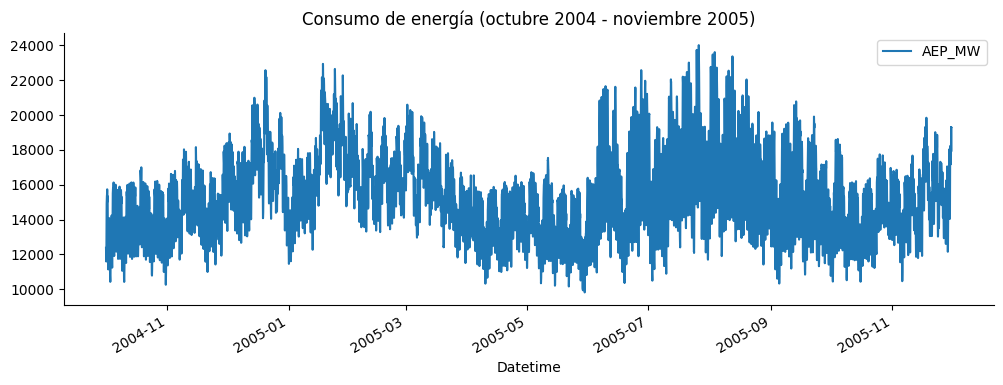

In [19]:
# Selección por fecha
df["2004-10":"2005-11"].plot(title="Consumo de energía (octubre 2004 - noviembre 2005)")

## 2. Remuestreo

| Alias | Descripción |
|-------|-------------|
| `s` | Frecuencia por segundo |
| `ms` | Frecuencia por milisegundo |
| `us` | Frecuencia por microsegundo |
| `ns` | Frecuencia por nanosegundo |
| `min` | Frecuencia por minuto (ej. `5min`) |
| `h` | Frecuencia por hora (ej. `12h`) |
| `D` | Frecuencia por día calendario |
| `B` | Frecuencia por día hábil (omite fines de semana) |
| `W` | Frecuencia semanal (por defecto domingos) |
| `W-MON`, `W-TUE`, … | Frecuencia semanal anclada a un día específico |
| `MS` | Inicio de mes (día 1) |
| `ME` | Fin de mes (último día) |
| `BMS` | Inicio de mes hábil |
| `BME` | Fin de mes hábil |
| `QS` | Inicio de trimestre |
| `QE` | Fin de trimestre |
| `YS` | Inicio de año |
| `YE` | Fin de año |

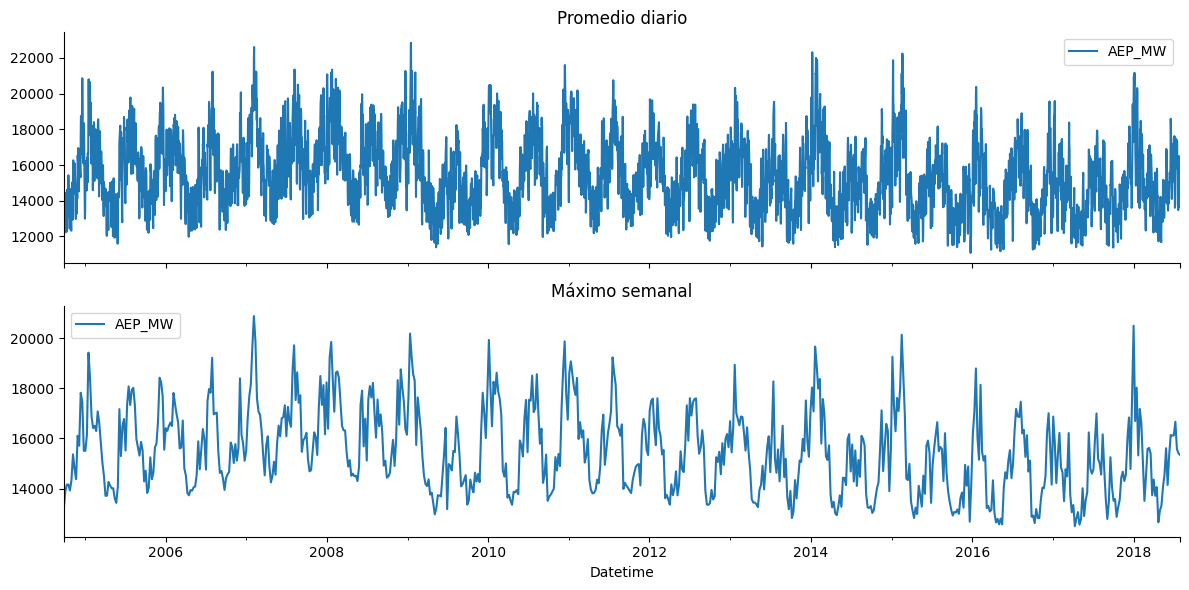

In [41]:
daily  = df.resample("D").mean() 
weekly = df.resample("W").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily.plot(ax=axes[0], title="Promedio diario")
weekly.plot(ax=axes[1], title="Máximo semanal")
plt.tight_layout()

## 3. Media móvil

In [36]:
#window.head(30)

window["shift_24"] = window["AEP_MW"].shift(24)
window.head(30)


,AEP_MW,rm_24h,rm_week,shift_24
Datetime,,,,
2004-10-01 01:00:00,12379.0,NaN,NaN,NaN
2004-10-01 02:00:00,11935.0,NaN,NaN,NaN
2004-10-01 03:00:00,11692.0,NaN,NaN,NaN
2004-10-01 04:00:00,11597.0,NaN,NaN,NaN
2004-10-01 05:00:00,11681.0,NaN,NaN,NaN
2004-10-01 06:00:00,12280.0,NaN,NaN,NaN
2004-10-01 07:00:00,13692.0,NaN,NaN,NaN
2004-10-01 08:00:00,14618.0,NaN,NaN,NaN
2004-10-01 09:00:00,14903.0,NaN,NaN,NaN


<Axes: title={'center': 'Media móvil — 24h y 1 semana'}, xlabel='Datetime'>

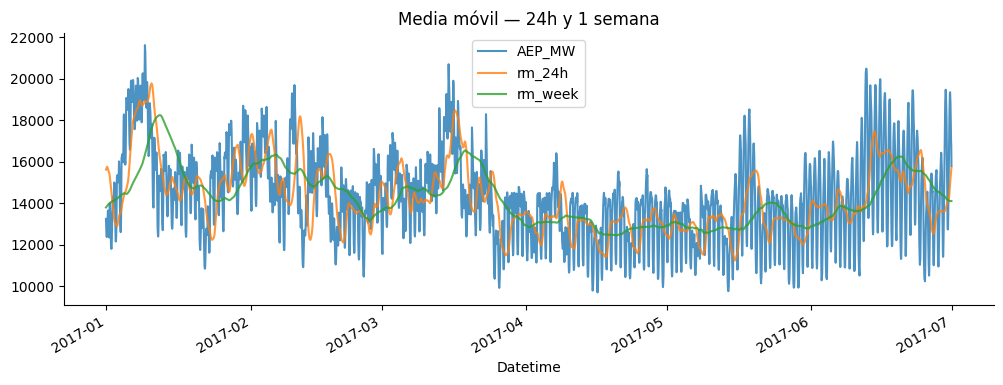

In [37]:
window = df.copy() #rolling
# Calcula la media móvil de 24 horas y 1 semana sin incluir el día actual 

#shift --> me mueve los indices de una tabla


window["rm_24h"] = window["AEP_MW"].shift(24).rolling(24).mean()
window["rm_week"] = window["AEP_MW"].shift(24).rolling(168).mean()


window[[ "AEP_MW","rm_24h", "rm_week"]] \
    .loc["2017-01":"2017-06"] \
    .plot(title="Media móvil — 24h y 1 semana", alpha=0.8)

## 4. Estacionalidad y diferenciación

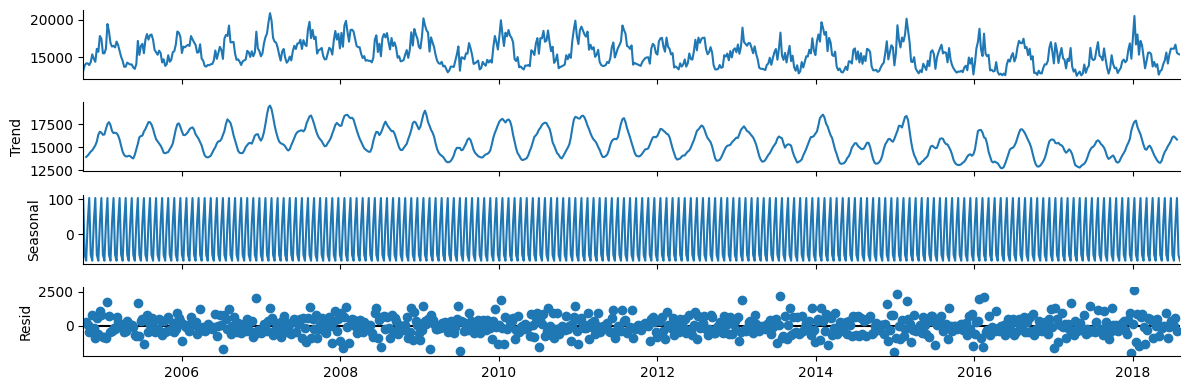

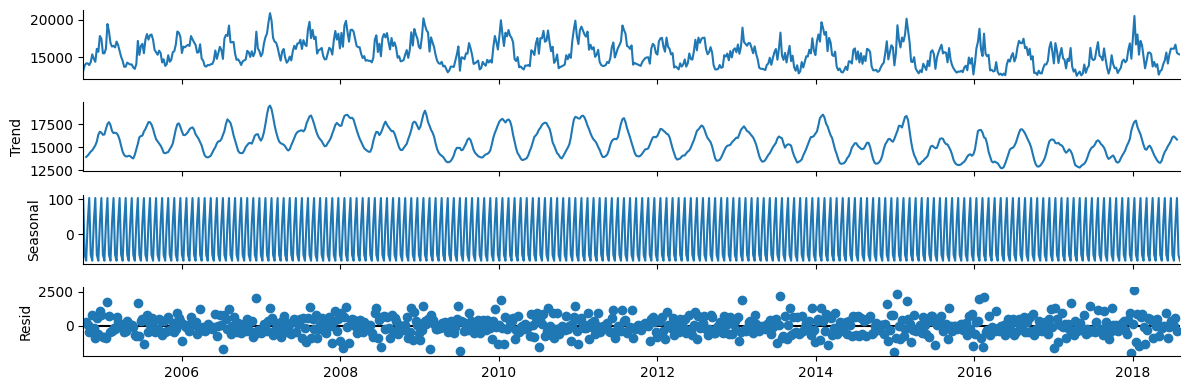

In [ ]:
# Descomposición de la serie temporal
seasonal_decompose(df.resample("W").mean(), model="additive",period=4).plot()

C:\Users\57304\AppData\Local\Temp\ipykernel_16328\4158631049.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  diff = df.resample("M").mean()


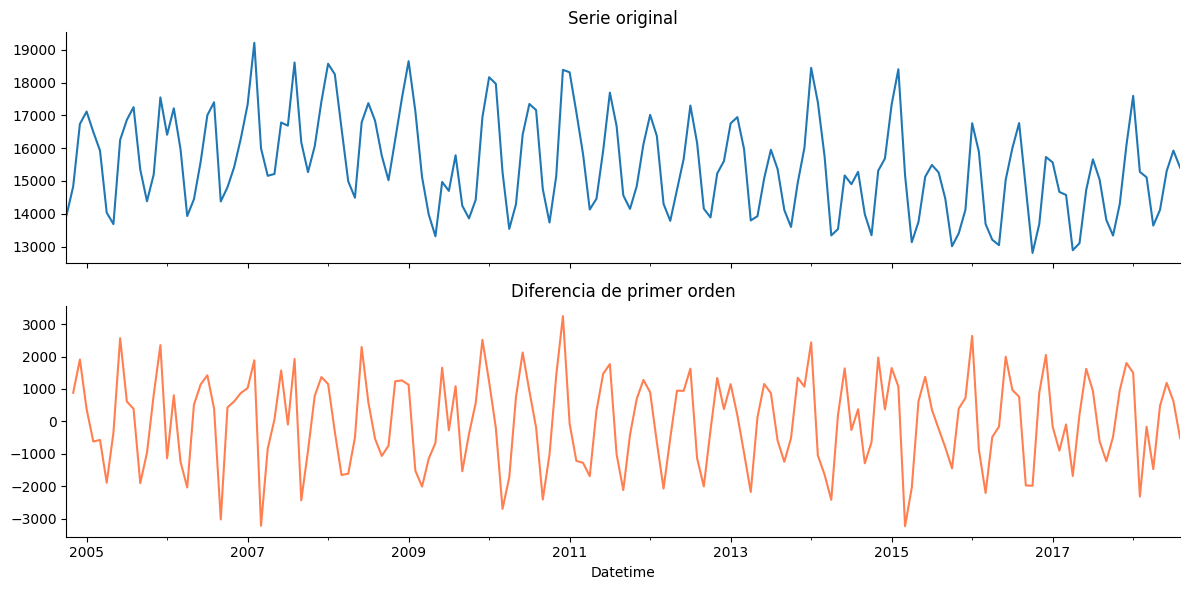

In [61]:
# Calcula la media semanal y la diferencia de primer orden

diff = df.resample("M").mean()
diff["diff_1"] = diff["AEP_MW"].diff()


fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
diff["AEP_MW"].plot(ax=axes[0], title="Serie original")
diff["diff_1"].plot(ax=axes[1], title="Diferencia de primer orden", color="coral")
plt.tight_layout()

In [81]:
#AUTOCORRELACIÓN --> correlación entre una serie temporal y una versión desplazada de sí misma. Se utiliza para identificar patrones repetitivos o estacionales en los datos. 
diff = df.resample("D").mean()
diff.head()
diff["AEP_MW"].autocorr(lag=168)



np.float64(0.47243020717049333)